# 4 site exact solutions

Created 21/05/2025

Objectives:
* Find exact solutions with boundary operators of width 4.

# Package imports

In [1]:
import sys
sys.path.append('../../')

In [2]:
import h5py
from tenpy.tools import hdf5_io
import tenpy
import tenpy.linalg.np_conserved as npc

import os
import pickle

In [3]:
from itertools import chain, combinations, product
from collections import defaultdict
from functools import reduce
import re

In [4]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

from matplotlib.ticker import AutoMinorLocator, MultipleLocator

In [5]:
from tqdm import tqdm

In [6]:
import quimb as qu
import quimb.tensor as qtn

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:54: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:73: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(


In [7]:
#from SPTOptimization.Optimizers.utils import to_npc_array

# Load data

In [8]:
DATA_DIR_1 = r"../../data/finite_cluster_x_transverse_to_product_stacked_cluster_interlayer_coupling_200_site"
DATA_DIR_2 = r"../../data/finite_x_product_stacked_transverse_y_cluster_to_product_interlayer_coupling_200_site"

In [9]:
loaded_data_1 = list()

for local_file_name in os.listdir(DATA_DIR_1):
    if local_file_name[-3:] == '.h5':
        f_name = r"{}/{}".format(DATA_DIR_1, local_file_name, ignore_unknown=False)
        with h5py.File(f_name, 'r') as f:
            data = hdf5_io.load_from_hdf5(f)
            loaded_data_1.append(data)

loaded_data_2 = list()

for local_file_name in os.listdir(DATA_DIR_2):
    if local_file_name[-3:] == '.h5':
        f_name = r"{}/{}".format(DATA_DIR_2, local_file_name, ignore_unknown=False)
        with h5py.File(f_name, 'r') as f:
            data = hdf5_io.load_from_hdf5(f)
            loaded_data_2.append(data)

In [10]:
t_parameters = sorted(list(d['paramters']['interpolation'] for d in loaded_data_1))

In [11]:
psi_dict = dict()

In [12]:
for b in t_parameters:
    mps_psi = next(
        d['wavefunction']
        for d in loaded_data_1
        if d['paramters']['interpolation'] == b
    )

    psi_arrays = list()
    psi_arrays.append(mps_psi.get_B(0, 'Th')[0, ...].to_ndarray())
    for i in range(1, mps_psi.L-1):
        psi_arrays.append(mps_psi.get_B(i).to_ndarray())
    psi_arrays.append(mps_psi.get_B(mps_psi.L-1)[..., 0].to_ndarray())

    quimb_psi = (
        qtn
        .tensor_1d
        .MatrixProductState(psi_arrays, shape='lpr')
    )

    rounded_b = round(b, 1)
    psi_dict[rounded_b] = quimb_psi

for b in t_parameters:
    mps_psi = next(
        d['wavefunction']
        for d in loaded_data_2
        if d['paramters']['interpolation'] == b
    )

    psi_arrays = list()
    psi_arrays.append(mps_psi.get_B(0, 'Th')[0, ...].to_ndarray())
    for i in range(1, mps_psi.L-1):
        psi_arrays.append(mps_psi.get_B(i).to_ndarray())
    psi_arrays.append(mps_psi.get_B(mps_psi.L-1)[..., 0].to_ndarray())

    quimb_psi = (
        qtn
        .tensor_1d
        .MatrixProductState(psi_arrays, shape='lpr')
    )

    rounded_b = round(b, 1)
    psi_dict[rounded_b+1] = quimb_psi

# Definitons

In [13]:
MAX_VIRTUAL_BOND_DIM = 8
MAX_INTERMEDIATE_VIRTUAL_BOND_DIM = 2*MAX_VIRTUAL_BOND_DIM
# MPO bond dim?
MAX_MPO_BOND_DIM = 50

SVD_CUTOFF = 1e-3

Define bosonic symmetries. Label by the group element added.

In [14]:
np_I = np.array([[1,0],[0,1]])
np_X = np.array([[0,1],[1,0]])
np_Y = np.array([[0,-1j],[1j,0]])
np_Z = np.array([[1,0],[0,-1]])

In [15]:
"""
npc_I = to_npc_array(np_I)
npc_X = to_npc_array(np_X)
npc_Y = to_npc_array(np_Y)
npc_Z = to_npc_array(np_Z)
"""

'\nnpc_I = to_npc_array(np_I)\nnpc_X = to_npc_array(np_X)\nnpc_Y = to_npc_array(np_Y)\nnpc_Z = to_npc_array(np_Z)\n'

In [15]:
def generate_problem_rdm(quimb_psi, symmetry_site_pairs, leftmost_symmetry_site,
                         num_symmetry_sites, num_boundary_sites,
                         antilinear=False, interior=False):
    # Being careful to conjugate the top tensors.
    q_top = quimb_psi.copy(deep=True)

    for i, s in symmetry_site_pairs:
        if antilinear:
            q_top[i].modify(
                data=q_top[i].data.conj()
            )
        q_top.gate(
            s,
            where=i,
            contract=False,
            inplace=True
        )

    shift = num_boundary_sites if interior else False
    left_boundary_sites = list(range(
        leftmost_symmetry_site-num_boundary_sites + shift,
        leftmost_symmetry_site+shift
    ))

    right_boundary_sites = list(range(
        leftmost_symmetry_site+num_symmetry_sites-shift,
        leftmost_symmetry_site+num_symmetry_sites+num_boundary_sites-shift
    ))
    
    indices_to_map = list(chain(left_boundary_sites, right_boundary_sites))

    index_mapping = {f'k{i}': f'b{i}' for i in indices_to_map}

    q_bottom = (
        quimb_psi
        .copy()
        .reindex(index_mapping, inplace=True)
        .conj()
    )

    sites_to_contract = {
        'left': list(range(leftmost_symmetry_site-num_boundary_sites+shift)),
        'middle': list(range(leftmost_symmetry_site+shift, leftmost_symmetry_site+num_symmetry_sites-shift)),
        'right': list(range(leftmost_symmetry_site+num_symmetry_sites+num_boundary_sites-shift, quimb_psi.L))
    }

    tags_to_contract = {
        k: [f'I{i}' for i in v]
        for k, v in sites_to_contract.items()
    }

    tn = (q_top & q_bottom)

    """
    tnc = (
        tn
        .contract(tags_to_contract['left'])
        .contract(tags_to_contract['middle'])
        .contract(tags_to_contract['right'])
    )
    """

    tnc = tn.contract()

    fuse_maps = [
        ('k_left', (f'k{i}' for i in left_boundary_sites)),
        ('b_left', (f'b{i}' for i in left_boundary_sites)),
        ('k_right', (f'k{i}' for i in right_boundary_sites)),
        ('b_right', (f'b{i}' for i in right_boundary_sites))
    ]

    tnc.fuse(fuse_maps, inplace=True)

    return tnc

## Optimisation functions

In [16]:
def solve_for_boundary_operators(rdm, num_iters=20):
    scores = list()

    # Hard code warning
    u_left = qtn.tensor_builder.rand_tensor(
        (16, 16),
        inds=['k_left', 'b_left'],
        dtype='complex64'
    )

    u_right = qtn.tensor_builder.rand_tensor(
        (16, 16),
        inds=['k_right', 'b_right'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_rdm = (rdm & u_left).contract()
        data = right_rdm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_right = qtn.Tensor(sol, inds = ['b_right', 'k_right'])
        
        left_rdm = (rdm & u_right).contract()
        data = left_rdm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_left = qtn.Tensor(sol, inds = ['b_left', 'k_left'])

    return (u_left, u_right), scores

## SPT functions

In [17]:
def calculate_proj_rep_phase(state_g, left_schmidt_values_g, unitary_h,
                             state_gh,
                             left_environment,
                             max_virtual_bond_dim=MAX_VIRTUAL_BOND_DIM):
    prod_state, _ = multiply_stacked_unitaries_against_mps(
        unitary_h,
        state_g,
        left_schmidt_values_g,
        max_virtual_bond_dim
    )

    exp = inner_product_b_tensors(prod_state, state_gh, left_environment)

    return exp/(np.abs(exp))

In [18]:
def get_proj_rep_phases(mps_tensors, left_schmidt_values, unitaries,
                        left_environment):
    mps_dict = {
        k: v for k, v in zip(symmetry_labels[1:], mps_tensors)
    }

    schmidt_vals_dict = {
        k: v for k, v in zip(symmetry_labels[1:], left_schmidt_values)
    }

    unitaries_dict = {
        k: v for k, v in zip(symmetry_labels[1:], unitaries)
    }

    out_phases = list()

    for a, b, c in group_products:
        phase = calculate_proj_rep_phase(
            mps_dict[a],
            schmidt_vals_dict[a],
            unitaries_dict[b],
            mps_dict[c],
            left_environment,
            max_virtual_bond_dim=MAX_VIRTUAL_BOND_DIM
        )

        out_phases.append(phase)

    return out_phases

In [19]:
def get_right_proj_rep_phases_from_optimizers(optimizers):
    mps_tensors = [
        o.top_right_mps_tensors
        for o in optimizers[1:]
    ]

    left_schmidt_values = [
        o.current_right_side_left_schmidt_values
        for o in optimizers[1:]
    ]

    unitaries = [
        o.right_unitaries for o in optimizers[1:]
    ]

    left_environment = optimizers[0].right_side_left_symmetry_environment

    out = get_proj_rep_phases(
        mps_tensors,
        left_schmidt_values,
        unitaries,
        left_environment
    )

    return out

In [20]:
def get_left_proj_rep_phases_from_optimizers(optimizers):
    mps_tensors = [
        o.top_left_mps_tensors
        for o in optimizers[1:]
    ]

    left_schmidt_values = [
        o.current_left_side_right_schmidt_values
        for o in optimizers[1:]
    ]

    unitaries = [
        o.left_unitaries for o in optimizers[1:]
    ]

    left_environment = optimizers[0].left_side_right_symmetry_environment

    out = get_proj_rep_phases(
        mps_tensors,
        left_schmidt_values,
        unitaries,
        left_environment
    )

    return out

## SPT extraction functions

In [21]:
# Boolean indicates if the symmetry is anti-linear or not.
symmetry_actions = [
    ([np_I, np_I], False),
    ([np_X, np_I], False),
    ([np_I, np_X], True),
    ([np_X, np_X], True)
]

In [22]:
symmetry_labels = [
    'I-I',
    'X-I',
    'I-XK',
    'X-XK'
]

In [23]:
identity_element = 'I-I'

In [24]:
e, a, b, c = symmetry_labels

In [25]:
group_products = [
    (a, a, e),
    (b, b, e),
    (c, c, e),
    (a, b, c),
    (b, a, c),
    (a, c, b),
    (c, a, b),
    (b, c, a),
    (c, b, a),
]

In [26]:
group_products_dict = {
    (a,b): c for a,b,c in group_products
}

In [27]:
def multi_kron(arrays):
    return reduce(lambda X, Y: np.kron(X, Y), arrays)

In [28]:
symmetry_actions_dict = {
    'I-I': (np.identity(16), False),
    'X-I': (multi_kron([np_X, np_I, np_X, np_I]), False),
    'I-XK': (multi_kron([np_I, np_X, np_I, np_X]), True),
    'X-XK': (multi_kron([np_X, np_X, np_X, np_X]), True)
}

In [29]:
antilinear_dict = {
    e: False,
    a: False,
    b: True,
    c: True
}

In [30]:
def relabel_mpo(mpo, k_label, b_label):
    site_locs = [
        int(k[1:]) for k in mpo.tag_map
        if bool(re.search(regex_p, k))
    ]

    k_in_indices = [f'k{i}' for i in site_locs]
    j_in_indices = [f'b{i}' for i in site_locs]

    k_out_indices = [f'{k_label}{i}' for i in site_locs]
    j_out_indices = [f'{b_label}{i}' for i in site_locs]

    mapping = dict(
        chain(
            zip(k_in_indices, k_out_indices),
            zip(j_in_indices, j_out_indices)
        )
    )

    mpo.reindex(mapping, inplace=True)

In [31]:
def get_proj_rep_phase(rho, u_g, u_h, u_gh):
    m = (u_gh.conj().T) @ u_h @ u_g @ rho
    exp = np.trace(m)

    out = exp/np.abs(exp)

    return out

In [32]:
np_I_4 = np.identity(16)

In [33]:
# Duplicate definition here...!
def get_proj_rep_phases(rho, unitaries):
    out = list()

    unitaries_dict = {
        k: v for k, v in zip(symmetry_labels[1:], unitaries)
    }

    unitaries_dict['I-I'] = np_I_4

    out_phases = list()
    for a, b, c in group_products:
        phase = get_proj_rep_phase(
            rho,
            unitaries_dict[a],
            unitaries_dict[b],
            unitaries_dict[c]
        )

        out_phases.append(phase)

    return out_phases

In [34]:
# Hard code warning!
# This code might be assuming the group is Abelian? Check Kapustin index formula in nonAbelian case.
def get_exterior_proj_rep_phase_kapustin_rule(rho, u_g, u_h, u_gh, g_symmetry_label):
    g_sym, antilinear = symmetry_actions_dict[g_symmetry_label]

    m_h = u_h.conj() if antilinear else u_h

    m = (
        (u_gh.conj().T)
        @ m_h
        @ u_g
        @ rho
    )
    exp = np.trace(m)

    out = exp/np.abs(exp)

    return out

In [35]:
# Duplicate definition here...!
def get_exterior_proj_rep_phases_kapustin_rule(rho, unitaries):
    out = list()

    unitaries_dict = {
        k: v for k, v in zip(symmetry_labels[1:], unitaries)
    }

    unitaries_dict['I-I'] = np_I_4

    out_phases = list()
    for a, b, c in group_products:
        phase = get_exterior_proj_rep_phase_kapustin_rule(
            rho,
            unitaries_dict[a],
            unitaries_dict[b],
            unitaries_dict[c],
            a
        )

        out_phases.append(phase)

    return out_phases

In [36]:
# Hard code warning!
# This code might be assuming the group is Abelian? Check Kapustin index formula in nonAbelian case.
def get_interior_proj_rep_phase(rho, u_g, u_h, u_gh, g_symmetry_label):
    g_sym, antilinear = symmetry_actions_dict[g_symmetry_label]

    m_h = u_h.conj() if antilinear else u_h

    m = (
        (u_gh.conj().T)
        @ g_sym
        @ m_h
        @ (g_sym.conj().T)
        @ u_g
        @ rho
    )
    exp = np.trace(m)

    out = exp/np.abs(exp)

    return out

In [37]:
# Duplicate definition here...!
def get_interior_proj_rep_phases(rho, unitaries):
    out = list()

    unitaries_dict = {
        k: v for k, v in zip(symmetry_labels[1:], unitaries)
    }

    unitaries_dict['I-I'] = np_I_4

    out_phases = list()
    for a, b, c in group_products:
        phase = get_interior_proj_rep_phase(
            rho,
            unitaries_dict[a],
            unitaries_dict[b],
            unitaries_dict[c],
            a
        )

        out_phases.append(phase)

    return out_phases

## Cocycle checks

In [38]:
def omega_lookup(proj_rep_phases_array, g, h):
    if (g == identity_element) or (h == identity_element):
        return np.ones(shape=proj_rep_phases_array.shape[:-1], dtype=np.complex128)
    index = next(
        i for i, (a,b,c) in enumerate(group_products)
        if (a,b) == (g,h)
    )

    return proj_rep_phases_array[..., index]

In [39]:
def cocyle_check(proj_rep_phases_array, g, h, k, twisted=False):
    X = omega_lookup(proj_rep_phases_array, h, k)
    if antilinear_dict[g] and twisted:
        X = X.conj()

    cocycle_array = (
        X*omega_lookup(proj_rep_phases_array, g, group_products_dict[(h,k)])
        /(
            omega_lookup(proj_rep_phases_array, g, h)
            *omega_lookup(proj_rep_phases_array, group_products_dict[(g,h)], k)
        )
    )

    return cocycle_array

In [40]:
def check_cocycle_equation(proj_rep_phases_array, twisted=False):
    arrays = list()

    for g,h,k in product(symmetry_labels[1:], repeat=3):
        arrays.append(cocyle_check(proj_rep_phases_array, g,h,k, twisted))

    out = np.stack(arrays, axis=-1)

    return out

# Calculate boundary operators
## Exterior

In [41]:
num_boundary_sites=4
leftmost_symmetry_site=60
left_most_symmetry_site=leftmost_symmetry_site
num_symmetry_sites=80

symmetry_sites = list(range(
    leftmost_symmetry_site,
    leftmost_symmetry_site+num_symmetry_sites
))

In [42]:
num_iterations = 3

In [43]:
exterior_results_dict = dict()

for k1, psi in tqdm(psi_dict.items()):
    for k2, (bs, antilinear) in enumerate(symmetry_actions[1:], start=1):
        symmetry_site_pairs = (
            [(i, bs[0]) for i in range(left_most_symmetry_site, left_most_symmetry_site+num_symmetry_sites, 2)]
            + [(i, bs[1]) for i in range(left_most_symmetry_site+1, left_most_symmetry_site+num_symmetry_sites+1, 2)]
        )
    
        rdm = generate_problem_rdm(
            psi,
            symmetry_site_pairs,
            leftmost_symmetry_site,
            num_symmetry_sites,
            num_boundary_sites,
            antilinear=antilinear
        )
    
        (u_left, u_right), scores = solve_for_boundary_operators(
            rdm,
            num_iters=num_iterations
        )
    
        exterior_results_dict[(k1, k2)] = (u_left, u_right), scores

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [01:19<00:00,  3.81s/it]


### Check results

In [44]:
t_params = np.round(np.linspace(0, 2, 21), 1)

In [45]:
t_params

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
       1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. ])

In [46]:
exterior_scores = list()
for t in t_params:

    exterior_scores.append([exterior_results_dict[(t, i)][1][-1] for i in [1,2,3]])

exterior_scores = np.array(exterior_scores)

In [47]:
colors = [
    'tab:blue',
    'tab:orange',
    'tab:green'
]   

Text(0.5, 0.98, 'Final overlap $\\vert c \\vert$ with symmetry $g$ as a function of $B$')

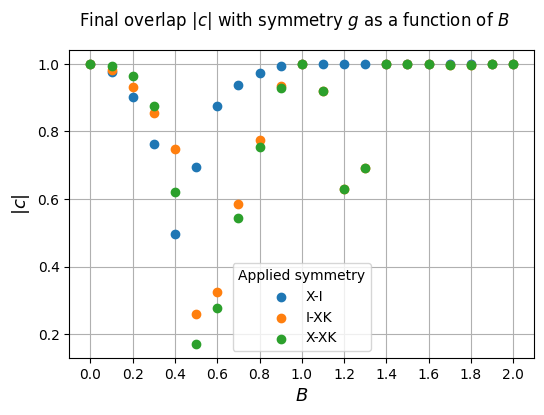

In [48]:
fig, ax = plt.subplots(figsize=(6,4))

for j, (col, label) in enumerate(zip(colors, symmetry_labels[1:])):
    plt.scatter(
        t_params,
        exterior_scores[:, j],
        color=col,
        label = label
    )

ax.xaxis.set_major_locator(
    matplotlib.ticker.MultipleLocator(0.2)
)

#ax.set_yscale('log')

ax.grid()
ax.grid(
    which='minor',
    axis='y',
    linestyle='--',
    zorder=-1e10
)
ax.set_axisbelow(True)

ax.set_ylabel(r'$\vert c\vert$', fontsize=13)
ax.set_xlabel('$B$', fontsize=13)

ax.legend(loc='lower center', title='Applied symmetry')

fig.suptitle(r'Final overlap $\vert c \vert$ with symmetry $g$ as a function of $B$')

#fig.savefig(r'plots/ed_cost_function_from_svd_bosonic.png', dpi=200)

In [49]:
proj_rep_phases = list()

for t in tqdm(t_params):
    psi = psi_dict[t]

    rdm = generate_problem_rdm(
        psi,
        [],
        leftmost_symmetry_site,
        num_symmetry_sites,
        num_boundary_sites
    )

    left_rdm = (
        rdm
        .trace('b_right', 'k_right')
        .transpose('k_left', 'b_left')
        .data
    )
    right_rdm = (
        rdm
        .trace('b_left', 'k_left')
        .transpose('k_right', 'b_right')
        .data
    )

    unitary_pairs = [exterior_results_dict[(t, i)][0] for i in [1,2,3]]
    left_unitaries, right_unitaries = zip(*unitary_pairs)

    left_unitaries = [
        lu.transpose('b_left', 'k_left').data
        for lu in left_unitaries
    ]

    right_unitaries = [
        ru.transpose('b_right', 'k_right').data
        for ru in right_unitaries
    ]
    left_phases = get_proj_rep_phases(left_rdm, left_unitaries)
    right_phases = get_proj_rep_phases(right_rdm, right_unitaries)

    proj_rep_phases.append([left_phases, right_phases])

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [00:24<00:00,  1.18s/it]


In [50]:
proj_rep_phases = np.array(proj_rep_phases)

In [51]:
proj_rep_phases.shape

(21, 2, 9)

In [52]:
np.round(proj_rep_phases, 3)

array([[[ 0.234-0.972j,  0.965+0.263j, -0.306+0.952j, -0.096+0.995j,
         -0.096+0.995j, -0.99 -0.14j , -0.99 -0.14j ,  0.17 -0.986j,
          0.17 -0.986j],
        [ 0.234+0.972j,  0.965-0.263j, -0.306-0.952j, -0.096-0.995j,
         -0.096-0.995j, -0.99 +0.14j , -0.99 +0.14j ,  0.17 +0.986j,
          0.17 +0.986j]],

       [[ 0.398+0.917j, -0.999-0.04j ,  0.995+0.102j, -0.522+0.853j,
         -0.522+0.853j,  0.575-0.818j,  0.575-0.818j,  0.488+0.873j,
          0.488+0.873j],
        [ 0.398-0.917j, -0.999+0.04j ,  0.995-0.102j, -0.522-0.853j,
         -0.522-0.853j,  0.575+0.818j,  0.575+0.818j,  0.488-0.873j,
          0.488-0.873j]],

       [[ 0.702+0.713j, -0.35 +0.937j,  0.744+0.668j, -0.544-0.839j,
         -0.544-0.839j, -0.98 +0.201j, -0.98 +0.201j, -0.595-0.804j,
         -0.595-0.804j],
        [ 0.702-0.713j, -0.35 -0.937j,  0.744-0.668j, -0.544+0.839j,
         -0.544+0.839j, -0.98 -0.201j, -0.98 -0.201j, -0.595+0.804j,
         -0.595+0.804j]],

       [[-0.197+

In [53]:
cocycle_check_array = check_cocycle_equation(proj_rep_phases, twisted=False)

In [54]:
np.max(np.abs(cocycle_check_array - 1))

3.692080085245272e-12

In [55]:
cocycle_check_array = check_cocycle_equation(proj_rep_phases, twisted=True)

In [56]:
np.max(np.abs(cocycle_check_array - 1))

1.999973424371729

In [57]:
proj_rep_phases = list()

for t in tqdm(t_params):
    psi = psi_dict[t]

    rdm = generate_problem_rdm(
        psi,
        [],
        leftmost_symmetry_site,
        num_symmetry_sites,
        num_boundary_sites
    )

    left_rdm = (
        rdm
        .trace('b_right', 'k_right')
        .transpose('k_left', 'b_left')
        .data
    )
    right_rdm = (
        rdm
        .trace('b_left', 'k_left')
        .transpose('k_right', 'b_right')
        .data
    )

    unitary_pairs = [exterior_results_dict[(t, i)][0] for i in [1,2,3]]
    left_unitaries, right_unitaries = zip(*unitary_pairs)

    left_unitaries = [
        lu.transpose('b_left', 'k_left').data
        for lu in left_unitaries
    ]

    right_unitaries = [
        ru.transpose('b_right', 'k_right').data
        for ru in right_unitaries
    ]
    left_phases = get_exterior_proj_rep_phases_kapustin_rule(left_rdm, left_unitaries)
    right_phases = get_exterior_proj_rep_phases_kapustin_rule(right_rdm, right_unitaries)

    proj_rep_phases.append([left_phases, right_phases])

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [00:27<00:00,  1.30s/it]


In [58]:
proj_rep_phases = np.array(proj_rep_phases)

In [59]:
proj_rep_phases.shape

(21, 2, 9)

In [60]:
np.round(proj_rep_phases, 3)

array([[[ 0.234-0.972j, -1.   +0.j   ,  1.   +0.j   , -0.096+0.995j,
          0.99 -0.14j , -0.99 -0.14j ,  0.096+0.995j, -0.99 +0.14j ,
          0.096+0.995j],
        [ 0.234+0.972j, -1.   +0.j   ,  1.   +0.j   , -0.096-0.995j,
          0.99 +0.14j , -0.99 +0.14j ,  0.096-0.995j, -0.99 -0.14j ,
          0.096-0.995j]],

       [[ 0.398+0.917j, -1.   +0.j   ,  1.   -0.j   , -0.522+0.853j,
         -0.575-0.818j,  0.575-0.818j,  0.522+0.853j,  0.575+0.818j,
          0.522+0.853j],
        [ 0.398-0.917j, -1.   +0.j   ,  1.   +0.j   , -0.522-0.853j,
         -0.575+0.818j,  0.575+0.818j,  0.522-0.853j,  0.575-0.818j,
          0.522-0.853j]],

       [[ 0.702+0.713j, -1.   -0.j   ,  1.   -0.j   , -0.544-0.839j,
          0.98 +0.201j, -0.98 +0.201j,  0.544-0.839j, -0.98 -0.201j,
          0.544-0.839j],
        [ 0.702-0.713j, -1.   -0.j   ,  1.   -0.j   , -0.544+0.839j,
          0.98 -0.201j, -0.98 -0.201j,  0.544+0.839j, -0.98 +0.201j,
          0.544+0.839j]],

       [[-0.197+

In [61]:
cocycle_check_array = check_cocycle_equation(proj_rep_phases, twisted=False)

In [62]:
np.max(np.abs(cocycle_check_array - 1))

1.9999734243717286

In [63]:
cocycle_check_array.shape

(21, 2, 27)

In [64]:
np.round(cocycle_check_array, 3)

array([[[ 1.   -0.j   ,  1.   +0.j   ,  1.   -0.j   , ...,
         -0.982+0.19j , -0.982+0.19j ,  1.   +0.j   ],
        [ 1.   +0.j   ,  1.   +0.j   ,  1.   +0.j   , ...,
         -0.982-0.19j , -0.982-0.19j ,  1.   +0.j   ]],

       [[ 1.   +0.j   ,  1.   +0.j   ,  1.   +0.j   , ...,
         -0.455+0.891j, -0.455+0.891j,  1.   +0.j   ],
        [ 1.   -0.j   ,  1.   -0.j   ,  1.   -0.j   , ...,
         -0.455-0.891j, -0.455-0.891j,  1.   +0.j   ]],

       [[ 1.   +0.j   ,  1.   +0.j   ,  1.   +0.j   , ...,
         -0.407-0.913j, -0.407-0.913j,  1.   +0.j   ],
        [ 1.   -0.j   ,  1.   -0.j   ,  1.   -0.j   , ...,
         -0.407+0.913j, -0.407+0.913j,  1.   +0.j   ]],

       ...,

       [[ 1.   +0.j   ,  1.   -0.j   ,  1.   -0.j   , ...,
         -0.905-0.425j, -0.905-0.425j,  1.   -0.j   ],
        [ 1.   -0.j   ,  1.   -0.j   ,  1.   -0.j   , ...,
         -0.905+0.425j, -0.905+0.425j,  1.   +0.j   ]],

       [[ 1.   +0.j   ,  1.   -0.j   ,  1.   -0.j   , ...,
        

In [65]:
cocycle_check_array = check_cocycle_equation(proj_rep_phases, twisted=True)

In [66]:
np.round(cocycle_check_array, 3)

array([[[ 1.   -0.j   ,  1.   +0.j   ,  1.   -0.j   , ...,
          1.   +0.j   ,  1.   -0.j   ,  1.   -0.j   ],
        [ 1.   +0.j   ,  1.   +0.j   ,  1.   +0.j   , ...,
          1.   +0.j   ,  1.   -0.j   ,  1.   -0.j   ]],

       [[ 1.   +0.j   ,  1.   +0.j   ,  1.   +0.j   , ...,
          1.   +0.j   ,  1.   +0.j   ,  1.   +0.j   ],
        [ 1.   -0.j   ,  1.   -0.j   ,  1.   -0.j   , ...,
          1.   +0.j   ,  1.   +0.j   ,  1.   -0.j   ]],

       [[ 1.   +0.j   ,  1.   +0.j   ,  1.   +0.j   , ...,
          1.   +0.j   ,  1.   -0.j   ,  1.   +0.j   ],
        [ 1.   -0.j   ,  1.   -0.j   ,  1.   -0.j   , ...,
          1.   -0.j   ,  1.   +0.j   ,  1.   +0.j   ]],

       ...,

       [[ 1.   +0.j   ,  1.   -0.j   ,  1.   -0.j   , ...,
          1.   +0.j   , -0.312+0.95j , -0.312+0.95j ],
        [ 1.   -0.j   ,  1.   -0.j   ,  1.   -0.j   , ...,
          1.   +0.j   ,  0.387-0.922j,  0.387-0.922j]],

       [[ 1.   +0.j   ,  1.   -0.j   ,  1.   -0.j   , ...,
        

In [67]:
np.max(np.abs(cocycle_check_array - 1))

1.997671731858975

## Interior

In [68]:
interior_results_dict = dict()

for k1, psi in tqdm(psi_dict.items()):
    for k2, (bs, antilinear) in enumerate(symmetry_actions[1:], start=1):
        symmetry_site_pairs = (
            [(i, bs[0]) for i in range(left_most_symmetry_site, left_most_symmetry_site+num_symmetry_sites, 2)]
            + [(i, bs[1]) for i in range(left_most_symmetry_site+1, left_most_symmetry_site+num_symmetry_sites+1, 2)]
        )
    
        rdm = generate_problem_rdm(
            psi,
            symmetry_site_pairs,
            leftmost_symmetry_site,
            num_symmetry_sites,
            num_boundary_sites,
            antilinear=antilinear,
            interior=True
            
        )
    
        (u_left, u_right), scores = solve_for_boundary_operators(
            rdm,
            num_iters=num_iterations
        )
    
        interior_results_dict[(k1, k2)] = (u_left, u_right), scores

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [01:27<00:00,  4.16s/it]


In [69]:
interior_scores = list()
for t in t_params:

    interior_scores.append([interior_results_dict[(t, i)][1][-1] for i in [1,2,3]])

interior_scores = np.array(interior_scores)

In [70]:
interior_scores

array([[1.        , 1.        , 1.        ],
       [0.97554879, 0.98171858, 0.99352006],
       [0.90060667, 0.93183018, 0.96328522],
       [0.76161929, 0.8542043 , 0.8756769 ],
       [0.50099982, 0.74761008, 0.62679282],
       [0.69520205, 0.28015522, 0.18509546],
       [0.87595074, 0.33772623, 0.28864335],
       [0.93568941, 0.58701423, 0.54357405],
       [0.97387981, 0.77442667, 0.75279665],
       [0.9941268 , 0.93326165, 0.92768274],
       [1.        , 1.        , 1.        ],
       [1.        , 0.92757978, 0.92757978],
       [1.        , 0.59724201, 0.59724201],
       [1.        , 0.69153902, 0.69153902],
       [1.        , 0.99975864, 0.99975864],
       [1.        , 0.99999999, 0.99999999],
       [1.        , 0.99994402, 0.99994402],
       [1.        , 0.99584233, 0.99584233],
       [1.        , 0.99690878, 0.99690878],
       [1.        , 0.99975439, 0.99975439],
       [1.        , 1.        , 1.        ]])

In [71]:
interior_scores - exterior_scores

array([[-2.22044605e-16, -2.22044605e-16,  0.00000000e+00],
       [-2.46469511e-14, -2.15383267e-14, -3.66373598e-15],
       [ 1.06124177e-05,  5.45447299e-06,  2.06717939e-05],
       [ 1.12936198e-04,  3.06759669e-05,  1.07535040e-04],
       [ 3.47679002e-03, -3.39139451e-05,  4.60693704e-03],
       [-5.56649721e-04,  2.00488998e-02,  1.29608860e-02],
       [-3.38852702e-04,  1.37822790e-02,  1.16095146e-02],
       [-3.23827459e-05,  3.48547674e-04,  2.49052682e-04],
       [-1.78161536e-05,  1.91728315e-05, -1.50340186e-05],
       [ 6.78069504e-07,  2.37708563e-07,  2.32731638e-07],
       [-6.66133815e-16, -6.66133815e-16, -5.55111512e-16],
       [-3.77475828e-15,  7.66902747e-03,  7.66902747e-03],
       [-1.77635684e-15, -3.13477070e-02, -3.13477070e-02],
       [-9.99200722e-16, -2.63652165e-06, -2.63652165e-06],
       [ 1.55431223e-15, -1.57943658e-11, -1.57952540e-11],
       [-1.99840144e-15,  1.11022302e-16,  3.33066907e-16],
       [-2.22044605e-16, -1.49880108e-14

Very small difference...

Text(0.5, 0.98, 'Final overlap $\\vert c \\vert$ with symmetry $g$ as a function of $B$')

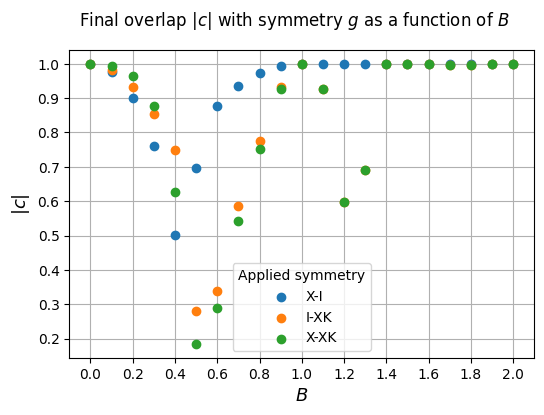

In [72]:
fig, ax = plt.subplots(figsize=(6,4))

for j, (col, label) in enumerate(zip(colors, symmetry_labels[1:])):
    plt.scatter(
        t_params,
        interior_scores[:, j],
        color=col,
        label = label
    )

ax.xaxis.set_major_locator(
    matplotlib.ticker.MultipleLocator(0.2)
)

#ax.set_yscale('log')

ax.grid()
ax.grid(
    which='minor',
    axis='y',
    linestyle='--',
    zorder=-1e10
)
ax.set_axisbelow(True)

ax.set_ylabel(r'$\vert c\vert$', fontsize=13)
ax.set_xlabel('$B$', fontsize=13)

ax.legend(loc='lower center', title='Applied symmetry')

fig.suptitle(r'Final overlap $\vert c \vert$ with symmetry $g$ as a function of $B$')

#fig.savefig(r'plots/ed_cost_function_from_svd_bosonic.png', dpi=200)

In [73]:
proj_rep_phases = list()

for t in tqdm(t_params):
    psi = psi_dict[t]

    rdm = generate_problem_rdm(
        psi,
        [],
        leftmost_symmetry_site,
        num_symmetry_sites,
        num_boundary_sites
    )

    left_rdm = (
        rdm
        .trace('b_right', 'k_right')
        .transpose('k_left', 'b_left')
        .data
    )
    right_rdm = (
        rdm
        .trace('b_left', 'k_left')
        .transpose('k_right', 'b_right')
        .data
    )

    unitary_pairs = [interior_results_dict[(t, i)][0] for i in [1,2,3]]
    left_unitaries, right_unitaries = zip(*unitary_pairs)

    left_unitaries = [
        lu.transpose('b_left', 'k_left').data
        for lu in left_unitaries
    ]
    right_unitaries = [
        ru.transpose('b_right', 'k_right').data
        for ru in right_unitaries
    ]

    left_phases = get_interior_proj_rep_phases(
        left_rdm,
        left_unitaries
    )
    right_phases = get_interior_proj_rep_phases(
        right_rdm,
        right_unitaries
    )

    proj_rep_phases.append([left_phases, right_phases])

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [00:29<00:00,  1.42s/it]


In [74]:
proj_rep_phases = np.array(proj_rep_phases)

In [75]:
proj_rep_phases.shape

(21, 2, 9)

In [76]:
proj_rep_phases.shape

(21, 2, 9)

In [77]:
np.round(proj_rep_phases, 3)

array([[[ 0.8  +0.6j  , -1.   +0.j   ,  1.   +0.j   ,  0.14 -0.99j ,
          0.482+0.876j, -0.482+0.876j, -0.14 -0.99j , -0.482-0.876j,
         -0.14 -0.99j ],
        [ 0.8  -0.6j  , -1.   -0.j   ,  1.   -0.j   ,  0.14 +0.99j ,
          0.482-0.876j, -0.482-0.876j, -0.14 +0.99j , -0.482+0.876j,
         -0.14 +0.99j ]],

       [[-0.859-0.511j, -1.   -0.j   ,  1.   +0.j   ,  0.998+0.056j,
          0.886-0.463j, -0.886-0.463j, -0.998+0.056j, -0.886+0.463j,
         -0.998+0.056j],
        [-0.859+0.511j, -1.   +0.j   ,  1.   +0.j   ,  0.998-0.056j,
          0.886+0.463j, -0.886+0.463j, -0.998-0.056j, -0.886-0.463j,
         -0.998-0.056j]],

       [[-1.   -0.001j, -1.   -0.j   ,  1.   +0.j   , -0.292-0.956j,
         -0.294-0.956j,  0.294-0.956j,  0.292-0.956j,  0.294+0.956j,
          0.292-0.956j],
        [-1.   +0.001j, -1.   -0.j   ,  1.   +0.j   , -0.292+0.956j,
         -0.294+0.956j,  0.294+0.956j,  0.292+0.956j,  0.294-0.956j,
          0.292+0.956j]],

       [[ 0.283-

In [78]:
cocycle_check_array = check_cocycle_equation(proj_rep_phases, twisted=False)

In [79]:
np.max(np.abs(cocycle_check_array - 1))

1.9999872584643203

In [80]:
cocycle_check_array.shape

(21, 2, 27)

In [81]:
np.round(cocycle_check_array, 3)

array([[[ 1.   +0.j   ,  1.   +0.j   ,  1.   +0.j   , ...,
         -0.961+0.277j, -0.961+0.277j,  1.   +0.j   ],
        [ 1.   +0.j   ,  1.   -0.j   ,  1.   -0.j   , ...,
         -0.961-0.277j, -0.961-0.277j,  1.   +0.j   ]],

       [[ 1.   -0.j   ,  1.   -0.j   ,  1.   -0.j   , ...,
          0.994-0.111j,  0.994-0.111j,  1.   +0.j   ],
        [ 1.   -0.j   ,  1.   -0.j   ,  1.   -0.j   , ...,
          0.994+0.111j,  0.994+0.111j,  1.   +0.j   ]],

       [[ 1.   -0.j   ,  1.   +0.j   ,  1.   +0.j   , ...,
         -0.829-0.559j, -0.829-0.559j,  1.   +0.j   ],
        [ 1.   -0.j   ,  1.   -0.j   ,  1.   -0.j   , ...,
         -0.829+0.559j, -0.829+0.559j,  1.   +0.j   ]],

       ...,

       [[ 1.   -0.j   ,  1.   -0.j   ,  1.   -0.j   , ...,
         -1.   -0.007j, -1.   -0.007j,  1.   +0.j   ],
        [ 1.   -0.j   ,  1.   -0.j   ,  1.   -0.j   , ...,
         -1.   +0.007j, -1.   +0.007j,  1.   +0.j   ]],

       [[ 1.   +0.j   ,  1.   +0.j   ,  1.   +0.j   , ...,
        

In [82]:
cocycle_check_array = check_cocycle_equation(proj_rep_phases, twisted=True)

In [83]:
np.round(cocycle_check_array, 3)

array([[[1.+0.j, 1.+0.j, 1.+0.j, ..., 1.+0.j, 1.-0.j, 1.-0.j],
        [1.+0.j, 1.-0.j, 1.-0.j, ..., 1.+0.j, 1.-0.j, 1.+0.j]],

       [[1.-0.j, 1.-0.j, 1.-0.j, ..., 1.-0.j, 1.-0.j, 1.-0.j],
        [1.-0.j, 1.-0.j, 1.-0.j, ..., 1.+0.j, 1.-0.j, 1.-0.j]],

       [[1.-0.j, 1.+0.j, 1.+0.j, ..., 1.-0.j, 1.-0.j, 1.-0.j],
        [1.-0.j, 1.-0.j, 1.-0.j, ..., 1.-0.j, 1.+0.j, 1.-0.j]],

       ...,

       [[1.-0.j, 1.-0.j, 1.-0.j, ..., 1.+0.j, 1.-0.j, 1.-0.j],
        [1.-0.j, 1.-0.j, 1.-0.j, ..., 1.+0.j, 1.+0.j, 1.+0.j]],

       [[1.+0.j, 1.+0.j, 1.+0.j, ..., 1.-0.j, 1.-0.j, 1.-0.j],
        [1.+0.j, 1.-0.j, 1.+0.j, ..., 1.-0.j, 1.-0.j, 1.-0.j]],

       [[1.+0.j, 1.+0.j, 1.+0.j, ..., 1.+0.j, 1.-0.j, 1.-0.j],
        [1.-0.j, 1.-0.j, 1.-0.j, ..., 1.-0.j, 1.+0.j, 1.-0.j]]])

In [84]:
np.max(np.abs(cocycle_check_array - 1))

3.6037895811990894e-11

# Conclusion
Same results as before...